In [1]:
# install.packages("tidyverse")
library(tidyverse)

# install.packages("corrplot")
library(corrplot)

# install.packages("moments")
library(moments)

# install.packages("car")
library(car)

# install.packages("lmtest")
library(lmtest)

# install.packages("tseries")
library(tseries)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded

Loading required package: carData


Attaching package: 'car'


The following object is masked from 'package:dplyr':

    recode


The following object is masked from 'package:purrr':

    some


Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



### 1. Importação de Dados através de [InsideAirbnb](https://insideairbnb.com/get-the-data/) -> Tasmania

In [2]:
# ler o dataset com c("", "NA") ficar já com valores ausentes como NA
dados <- read.csv("listings.csv", stringsAsFactors = TRUE, na.strings = c("", "NA"))

dim(dados) # quantidade de linhas e colunas

[1] 6501   18

In [3]:
head(dados, 5) # primeiras 5 linhas

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
,<dbl>,<fct>,<int>,<fct>,<lgl>,<fct>,<dbl>,<dbl>,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<int>,<int>,<int>,<fct>
1,35644,Central Hobart Historic Cottage,153268,Yvette,NA,Hobart,-42.87895,147.3153,Private room,NA,1,255,2020-03-08,1.64,3,0,0,Exempt: This listing falls under Section 12 of the Land Use Planning and Approvals Act 1993
2,88873,Terrace- 5mins to central Hobart,485048,Russell And Ingrid,NA,Hobart,-42.88219,147.3225,Entire home/apt,113,2,668,2025-09-04,3.83,1,147,50,Exempt: This listing falls under Section 12 of the Land Use Planning and Approvals Act 1993
3,137808,Bradman House CBD Launceston Invermay + Free WIFI,673625,Emma And Dale,NA,Launceston,-41.42548,147.1285,Entire home/apt,245,1,461,2025-09-09,2.79,2,287,49,DA0518/2019
4,268482,"Anderson Suite, The Ark Stanley, Guest House",1406692,Rhonda,NA,Circular Head,-40.76490,145.2970,Private room,344,1,5,2025-01-02,0.06,7,286,1,NA
5,292399,"Rainbow Valley Retreat, Ellendale",1513972,Mandy,NA,Central Highlands,-42.62103,146.7157,Private room,120,1,248,2025-06-09,1.60,1,362,26,NA


In [4]:
str(dados) # tipos de dados

'data.frame':	6501 obs. of  18 variables:
 $ id                            : num  35644 88873 137808 268482 292399 ...
 $ name                          : Factor w/ 6447 levels "''Birch Lane''  Self- Contained B&B, Cradoc/Cygnet",..: 1303 5290 1082 453 4175 4456 1862 2729 5799 4775 ...
 $ host_id                       : int  153268 485048 673625 1406692 1513972 1514295 1670767 1777929 2404373 2417230 ...
 $ host_name                     : Factor w/ 1656 levels "Aaron","Aaron And Emma",..: 1643 1332 452 1275 988 157 732 656 1472 76 ...
 $ neighbourhood_group           : logi  NA NA NA NA NA NA ...
 $ neighbourhood                 : Factor w/ 29 levels "Break O'Day",..: 15 15 21 6 5 15 14 19 21 27 ...
 $ latitude                      : num  -42.9 -42.9 -41.4 -40.8 -42.6 ...
 $ longitude                     : num  147 147 147 145 147 ...
 $ room_type                     : Factor w/ 4 levels "Entire home/apt",..: 3 1 1 3 3 3 1 3 1 1 ...
 $ price                         : int  NA 113 245 344

In [5]:
summary(dados) # estatísticas básicas

       id                                                            name     
 Min.   :3.564e+04   Ben Lomond Creek Cabins                           :   4  
 1st Qu.:2.812e+07   $0 No cleaning fee                                :   3  
 Median :5.400e+07   Anabel's Queen Room with Garden View              :   3  
 Mean   :5.239e+17   Aquila Eco Retreat - the ultimate romantic getaway:   3  
 3rd Qu.:1.060e+18   Bfst inc | Historic Glencoe Farmhouse Ensuite Room:   3  
 Max.   :1.507e+18   Leolanda's Airbnb! Private room in sunlit house   :   3  
                     (Other)                                           :6482  
    host_id                             host_name    neighbourhood_group
 Min.   :    22961   Moxxi                   : 142   Mode:logical       
 1st Qu.: 27146791   Emily                   : 129   NA's:6501          
 Median :100747967   Freycinet Holiday Houses: 103                      
 Mean   :175240250   Donna                   :  79                      
 3r

### 2. Limpeza de Dados

O que podemos observar de imediato com os outputs observados acima: 

- **price** tem **835 NAs** e sendo a variável alvo, estas linhas têm de ser removidas
- **price** tem um valor máximo de **15.108** com uma mediana de 198. O **outlier** tem de ser removido.
- **neighbourhood_group** tem tudo NA, logo é uma coluna facilmente descartável.
- **id, host_id, name, host_name** são colunas identificadoras, não têm valor preditivo nenhum. 
- **reviews_per_month** tem 369 NAs, logo são listings sem reviews, podemos imputar 0
- **minimum_nights** tem um max de 730, outlier

In [6]:
# Cópia de dados para limpeza
df <- dados

# Contar quantos valores ausentes existem em cada coluna
sapply(df, function(x) sum(is.na(x)))

id                           name 
                             0                              0 
                       host_id                      host_name 
                             0                              0 
           neighbourhood_group                  neighbourhood 
                          6501                              0 
                      latitude                      longitude 
                             0                              0 
                     room_type                          price 
                             0                            835 
                minimum_nights              number_of_reviews 
                             0                              0 
                   last_review              reviews_per_month 
                           369                            369 
calculated_host_listings_count               availability_365 
                             0                              0 
         number_of_reviews_ltm                        license 
                             0                            260

### Justificação das variáveis removidas

As seguintes colunas foram excluídas do modelo por razões específicas: 

* **neighbourhood_group**: completamente vazia (6501 NAs)

* **id** e **host_id**: identificadores únicos, não descrevem características do alojamento

* **name** e **host_name**: texto livre e demasiado específico; não generalizável num modelo de regressão

* **license**: 2480 níveis distintos, maioritariamente texto livre

* **last_review**: data em formato texto; a conversão para "dias desde última review" foi considerada mas 'reviews_per_month' e 'number_of_reviews_ltm' já capturam a atividade recente do alojamento de forma mais direta

* **calculated_host_listings_count**: fortemente assimétrica (max=142) e com correlação elevada com outras variáveis de review; removida para evitar multicolinearidade

In [7]:
# Remocao de colunas
df <- dplyr::select(df, -id, -name, -host_id, -host_name,
                    -neighbourhood_group, -license, -last_review,
                    -calculated_host_listings_count)

# Remocao de linhas com NA na variavel alvo (price)
df <- df %>% drop_na(price)

# Alojamentos sem avaliacoes ainda nao tem reviews, substituir NA por 0
df$reviews_per_month[is.na(df$reviews_per_month)] <- 0

# Remocao de alojamentos com minimo de noites superior a 30
# Acima deste valor, os alojamentos enquadram-se em arrendamentos de longa duracao
# e tem um comportamento de precos distinto dos alojamentos de curta estadia
df <- df %>% filter(minimum_nights <= 30)

# Remocao de outliers de preco acima do percentil 99
limite_superior <- quantile(df$price, 0.99)
df <- df[df$price <= limite_superior, ]

In [8]:
# Verificação: confirmar que não restam NAs no dataset
is.na(df) %>% sum()

[1] 0

In [9]:
# Certificação que nenhuma variável tem desvio padrão = 0
sd_values <- df %>%
  summarise(across(where(is.numeric), sd))
sd_values


latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,number_of_reviews_ltm
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.827514,0.7554613,123.7131,1.646114,140.0409,1.886356,101.1752,22.90984


In [10]:
str(df)
summary(df)

'data.frame':	5602 obs. of  10 variables:
 $ neighbourhood        : Factor w/ 29 levels "Break O'Day",..: 15 21 6 5 15 14 21 27 1 15 ...
 $ latitude             : num  -42.9 -41.4 -40.8 -42.6 -42.9 ...
 $ longitude            : num  147 147 145 147 147 ...
 $ room_type            : Factor w/ 4 levels "Entire home/apt",..: 1 1 3 3 3 1 1 1 1 1 ...
 $ price                : int  113 245 344 120 48 223 311 390 315 210 ...
 $ minimum_nights       : int  2 1 1 1 2 2 2 2 2 1 ...
 $ number_of_reviews    : int  668 461 5 248 160 59 481 80 96 23 ...
 $ reviews_per_month    : num  3.83 2.79 0.06 1.6 1.03 0.5 3.12 0.55 0.66 0.45 ...
 $ availability_365     : int  147 287 286 362 348 244 335 299 315 326 ...
 $ number_of_reviews_ltm: int  50 49 1 26 14 5 52 2 6 9 ...


              neighbourhood     latitude        longitude    
 Hobart              :1067   Min.   :-43.58   Min.   :143.8  
 Launceston          : 587   1st Qu.:-42.89   1st Qu.:147.1  
 Glamorgan/Spring Bay: 515   Median :-42.15   Median :147.3  
 Kingborough         : 409   Mean   :-42.14   Mean   :147.2  
 Clarence            : 377   3rd Qu.:-41.42   3rd Qu.:147.4  
 Break O'Day         : 335   Max.   :-39.69   Max.   :148.3  
 (Other)             :2312                                   
           room_type        price       minimum_nights   number_of_reviews
 Entire home/apt:5019   Min.   : 32.0   Min.   : 1.000   Min.   :   0.0   
 Hotel room     :  59   1st Qu.:149.0   1st Qu.: 1.000   1st Qu.:  14.0   
 Private room   : 524   Median :197.0   Median : 2.000   Median :  48.0   
 Shared room    :   0   Mean   :227.7   Mean   : 1.823   Mean   : 101.9   
                        3rd Qu.:270.0   3rd Qu.: 2.000   3rd Qu.: 132.0   
                        Max.   :958.0   Max.   :30.000

In [11]:
unique(df$room_type)
print("Contagem de cada tipo de quarto no df pré limpeza de NA's:")
table(dados$room_type)

# 'room_type' tem 4 níveis, mas só 3 são relevantes para o nosso modelo (então vamos eliminar o Shared Room, que ficou com 0 valores)
df$room_type <- droplevels(df$room_type)

print("Contagem de cada tipo de quarto no df pós limpeza de NA's:")
table(df$room_type)

[1] Entire home/apt Private room    Hotel room     
Levels: Entire home/apt Hotel room Private room Shared room

[1] "Contagem de cada tipo de quarto no df pré limpeza de NA's:"



Entire home/apt      Hotel room    Private room     Shared room 
           5721              81             698               1 

[1] "Contagem de cada tipo de quarto no df pós limpeza de NA's:"



Entire home/apt      Hotel room    Private room 
           5019              59             524 

In [12]:
# Vamos verificar se o mesmo aconteceu em neighbourhood
table(df$neighbourhood)


         Break O'Day             Brighton               Burnie 
                 335                   10                   53 
       Central Coast    Central Highlands        Circular Head 
                 141                   65                  131 
            Clarence       Derwent Valley            Devonport 
                 377                   73                  103 
              Dorset             Flinders          George Town 
                 180                   28                   61 
Glamorgan/Spring Bay            Glenorchy               Hobart 
                 515                  117                 1067 
         Huon Valley              Kentish          King Island 
                 216                  106                   37 
         Kingborough              Latrobe           Launceston 
                 409                   72                  587 
      Meander Valley    Northern Midlands               Sorell 
                 110                   

In [13]:
# Verificação final dos dados para ver se está tudo OK
head(df)
summary(df)

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,number_of_reviews_ltm
,<fct>,<dbl>,<dbl>,<fct>,<int>,<int>,<int>,<dbl>,<int>,<int>
1,Hobart,-42.88219,147.3225,Entire home/apt,113,2,668,3.83,147,50
2,Launceston,-41.42548,147.1285,Entire home/apt,245,1,461,2.79,287,49
3,Circular Head,-40.76490,145.2970,Private room,344,1,5,0.06,286,1
4,Central Highlands,-42.62103,146.7157,Private room,120,1,248,1.60,362,26
5,Hobart,-42.86919,147.3000,Private room,48,2,160,1.03,348,14
6,Glenorchy,-42.77935,147.2560,Entire home/apt,223,2,59,0.50,244,5


              neighbourhood     latitude        longitude    
 Hobart              :1067   Min.   :-43.58   Min.   :143.8  
 Launceston          : 587   1st Qu.:-42.89   1st Qu.:147.1  
 Glamorgan/Spring Bay: 515   Median :-42.15   Median :147.3  
 Kingborough         : 409   Mean   :-42.14   Mean   :147.2  
 Clarence            : 377   3rd Qu.:-41.42   3rd Qu.:147.4  
 Break O'Day         : 335   Max.   :-39.69   Max.   :148.3  
 (Other)             :2312                                   
           room_type        price       minimum_nights   number_of_reviews
 Entire home/apt:5019   Min.   : 32.0   Min.   : 1.000   Min.   :   0.0   
 Hotel room     :  59   1st Qu.:149.0   1st Qu.: 1.000   1st Qu.:  14.0   
 Private room   : 524   Median :197.0   Median : 2.000   Median :  48.0   
                        Mean   :227.7   Mean   : 1.823   Mean   : 101.9   
                        3rd Qu.:270.0   3rd Qu.: 2.000   3rd Qu.: 132.0   
                        Max.   :958.0   Max.   :30.000

In [14]:
# Transformacao logaritmica do preco para corrigir a assimetria da distribuicao
df <- df %>%
  mutate(log_price = log(price))

### 3. Exploração dos Dados

In [15]:
# Criar subconjunto apenas com variaveis numericas para analise
# Excluir latitude e longitude pois serao usadas apenas no mapa
df_numeric <- df %>%
  dplyr::select(price, minimum_nights, number_of_reviews,
                reviews_per_month, availability_365, number_of_reviews_ltm) 

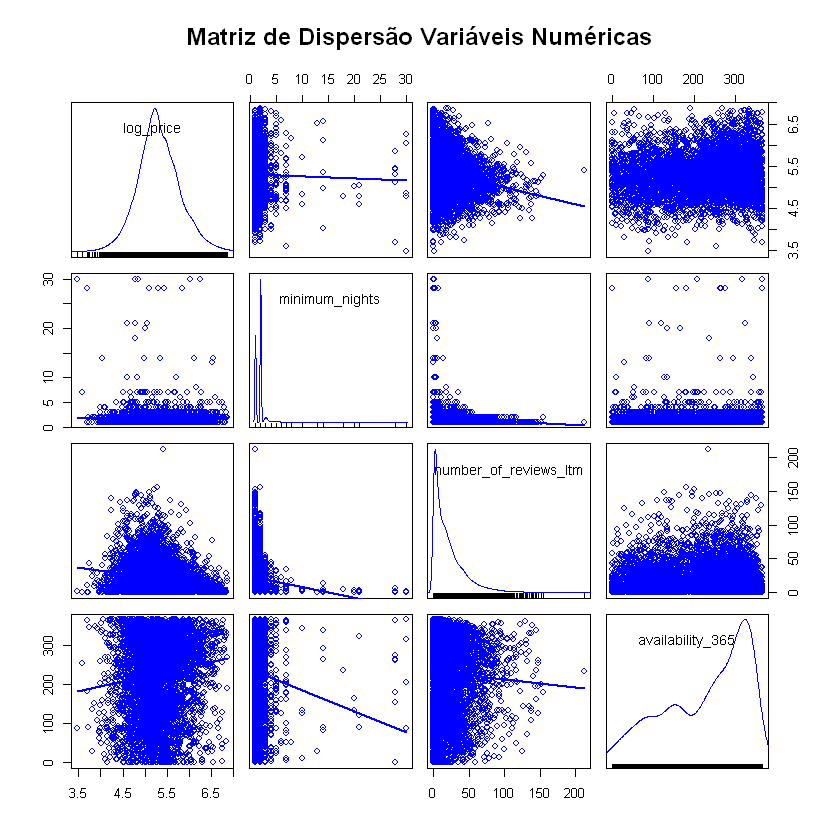

In [16]:
# Scatter Plot

par(bg = "white")  # definir fundo branco 
scatterplotMatrix(
  ~ log_price + minimum_nights + number_of_reviews_ltm + availability_365,
  data   = df,
  smooth = FALSE,
  main   = "Matriz de Dispersão Variáveis Numéricas"
)

#### Distribuição de Preço (Price)

O histograma é _right-skewed_, dado que existem propriedades de luxo - _outliers_ - com preços por noite bastante acima da média 

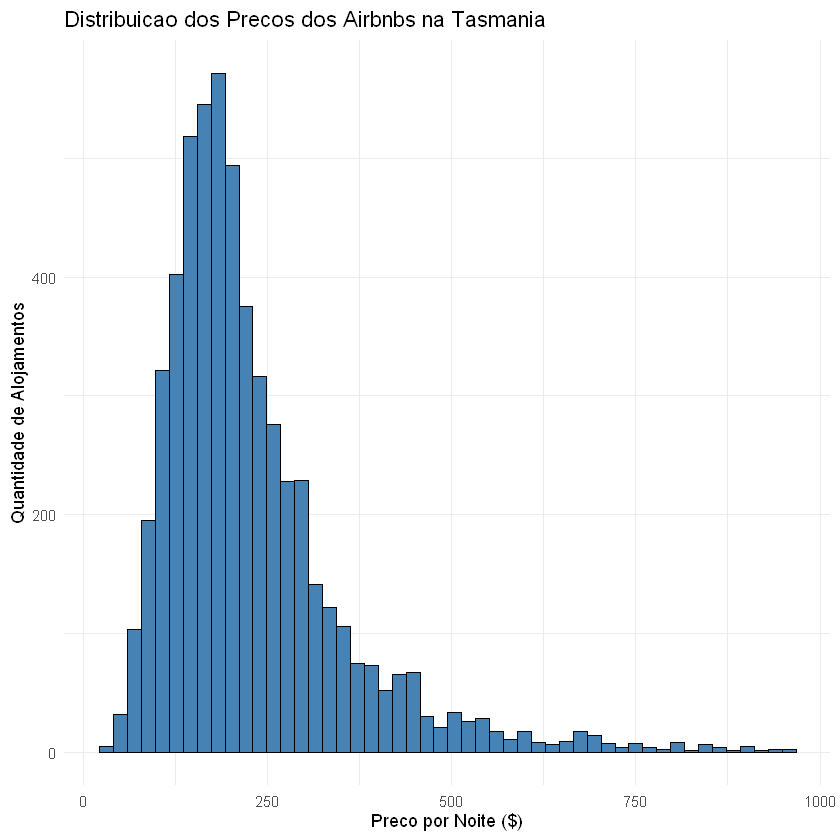

In [17]:
# Distribuicao do preco (variavel alvo)
ggplot(df, aes(x = price)) +
  geom_histogram(fill = "steelblue", color = "black", bins = 50) +
  theme_minimal() +
  labs(title = "Distribuicao dos Precos dos Airbnbs na Tasmania",
       x = "Preco por Noite ($)",
       y = "Quantidade de Alojamentos")

### Preço vs Tipo de Quarto

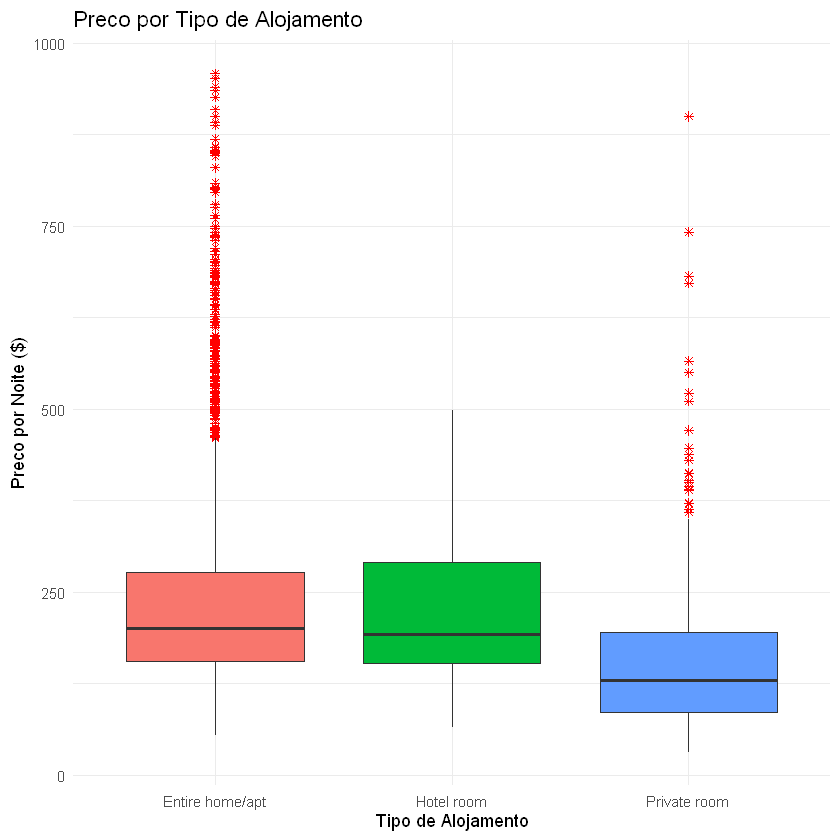

In [18]:
# Distribuicao do preco por tipo de alojamento
ggplot(df, aes(x = room_type, y = price, fill = room_type)) +
  geom_boxplot(outlier.color = "red", outlier.shape = 8) +
  theme_minimal() +
  labs(title = "Preco por Tipo de Alojamento",
       x = "Tipo de Alojamento",
       y = "Preco por Noite ($)") +
  theme(legend.position = "none")

### Visuaização das propriedades em coordenadas

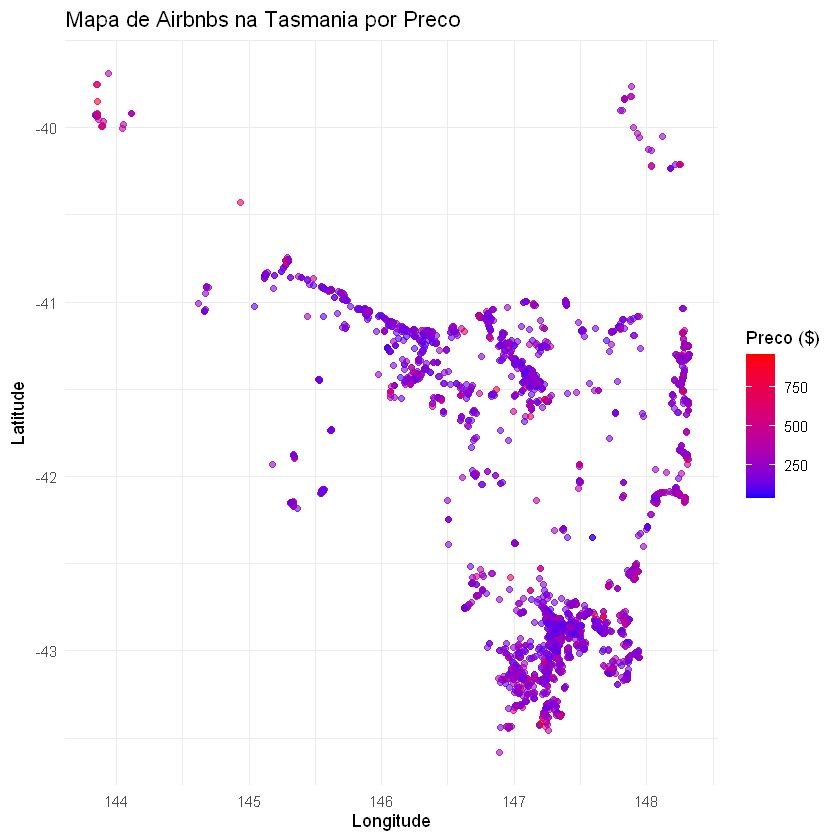

In [19]:
# Mapa de localizacao dos alojamentos colorido pelo preco
ggplot(df, aes(x = longitude, y = latitude, color = price)) +
  geom_point(alpha = 0.6, size = 1.5) +
  scale_color_gradient(low = "blue", high = "red") +
  theme_minimal() +
  labs(title = "Mapa de Airbnbs na Tasmania por Preco",
       x = "Longitude",
       y = "Latitude",
       color = "Preco ($)")

### Disponibilidade 365 dias vs Preço

`geom_smooth()` using formula = 'y ~ x'


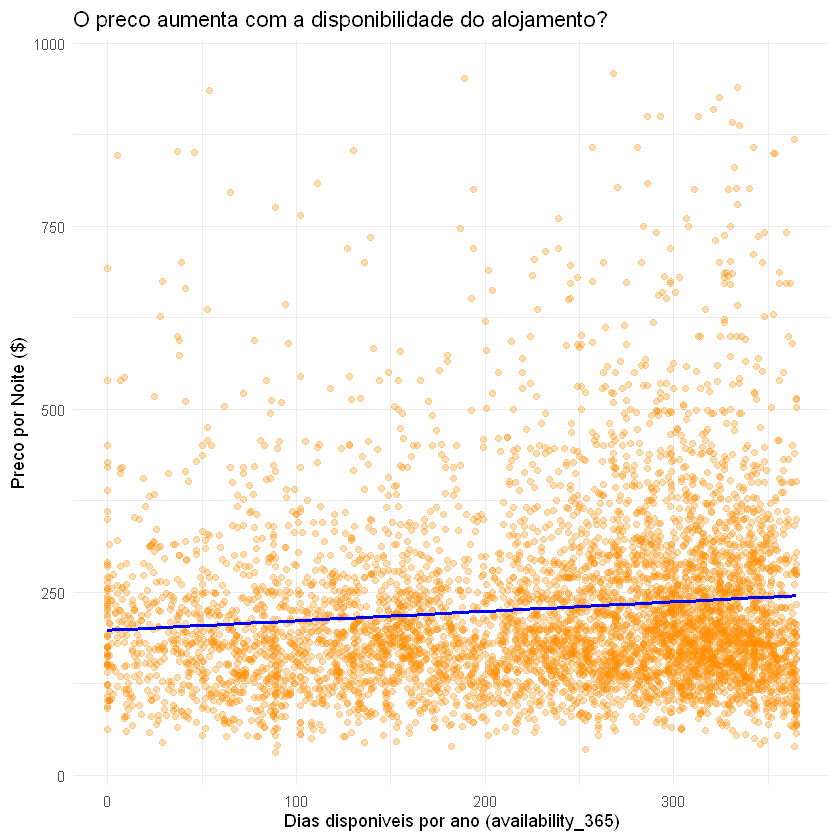

In [20]:
# Relacao entre disponibilidade anual e preco
ggplot(df, aes(x = availability_365, y = price)) +
  geom_point(alpha = 0.3, color = "darkorange") +
  geom_smooth(method = "lm", color = "blue", se = FALSE) +
  theme_minimal() +
  labs(title = "O preco aumenta com a disponibilidade do alojamento?",
       x = "Dias disponiveis por ano (availability_365)",
       y = "Preco por Noite ($)")

### Top 10 Bairros com mais Airbnbs

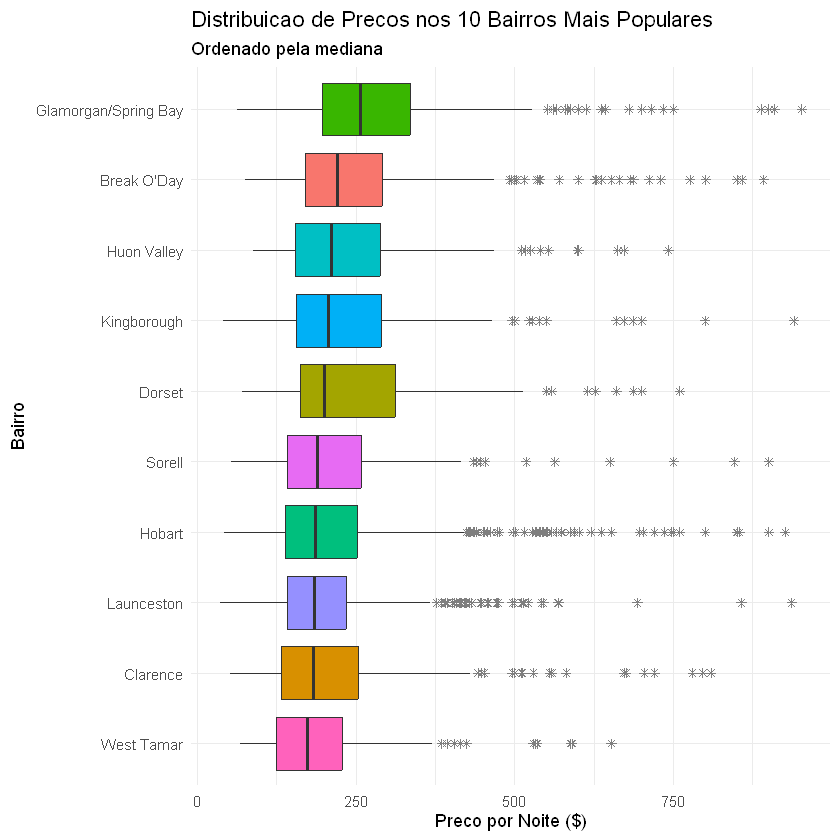

In [21]:
# Distribuicao de precos nos 10 bairros com mais alojamentos
top_10_bairros <- df %>%
  as_tibble() %>%
  dplyr::count(neighbourhood, sort = TRUE) %>%
  head(10) %>%
  dplyr::pull(neighbourhood)

df %>%
  dplyr::filter(neighbourhood %in% top_10_bairros) %>%
  ggplot(aes(x = reorder(neighbourhood, price, FUN = median),
             y = price,
             fill = neighbourhood)) +
  geom_boxplot(outlier.color = "gray50", outlier.shape = 8) +
  coord_flip() +
  theme_minimal() +
  labs(title = "Distribuicao de Precos nos 10 Bairros Mais Populares",
       subtitle = "Ordenado pela mediana",
       x = "Bairro",
       y = "Preco por Noite ($)") +
  theme(legend.position = "none")

### Distribuição do número mínimo de noites

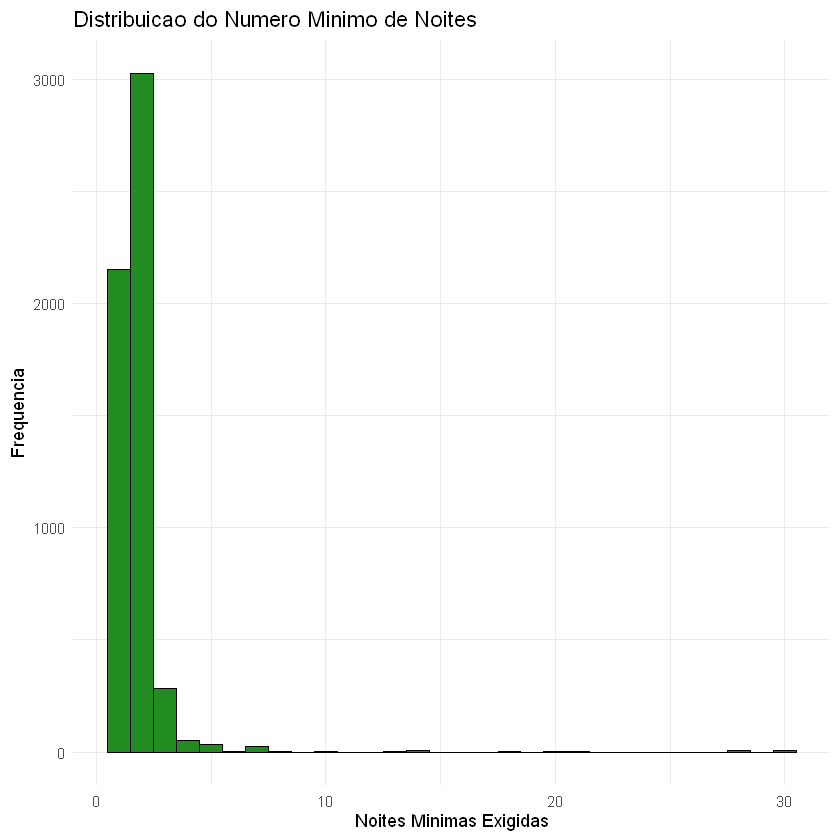

In [22]:
# Distribuicao do numero minimo de noites exigido
ggplot(df, aes(x = minimum_nights)) +
  geom_histogram(fill = "forestgreen", color = "black", bins = 30) +
  theme_minimal() +
  labs(title = "Distribuicao do Numero Minimo de Noites",
       x = "Noites Minimas Exigidas",
       y = "Frequencia")

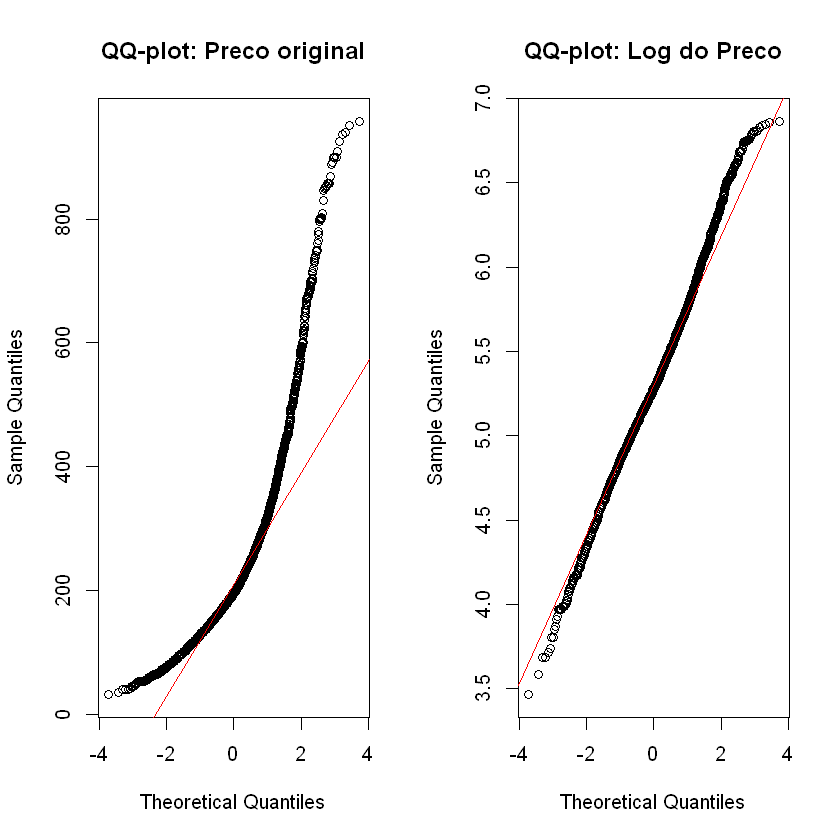

In [23]:
# QQ plot para conferir normalidade do preco original e do log do preco
par(mfrow = c(1, 2))
par(bg = "white")
qqnorm(df$price, main = "QQ-plot: Preco original")
qqline(df$price, col = "red")

qqnorm(df$log_price, main = "QQ-plot: Log do Preco")
qqline(df$log_price, col = "red")
par(mfrow = c(1, 1))

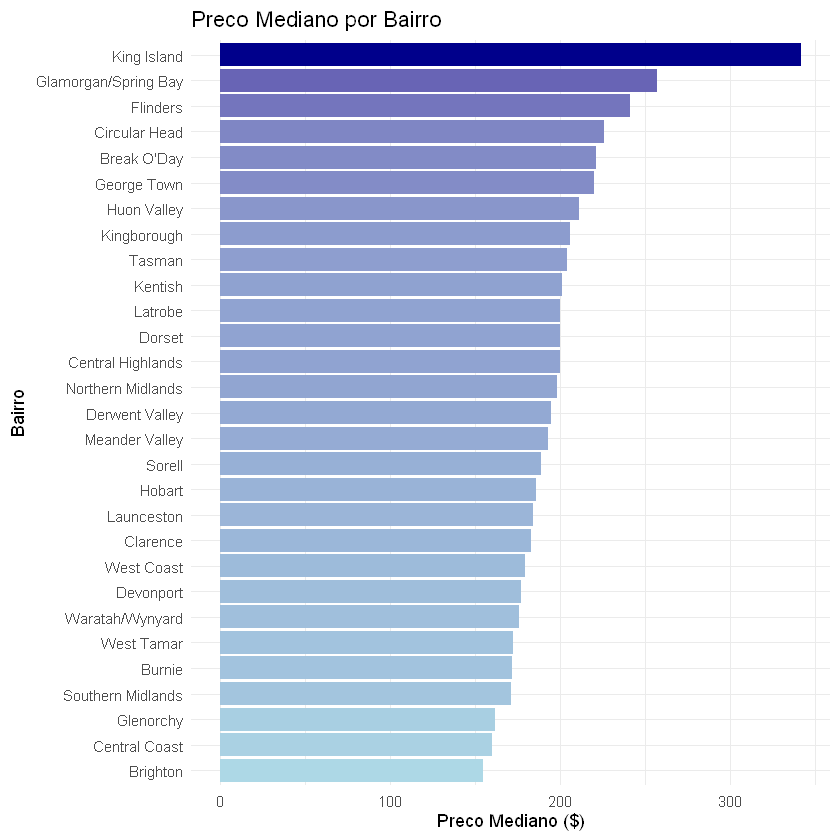

In [24]:
# Preço mediano por bairro
df %>%
  group_by(neighbourhood) %>%
  summarise(preco_mediano = median(price)) %>%
  ggplot(aes(x = reorder(neighbourhood, preco_mediano), y = preco_mediano, fill = preco_mediano)) +
  geom_col() +
  coord_flip() +
  scale_fill_gradient(low = "lightblue", high = "darkblue") +
  theme_minimal() +
  labs(title = "Preco Mediano por Bairro",
       x = "Bairro",
       y = "Preco Mediano ($)") +
  theme(legend.position = "none")

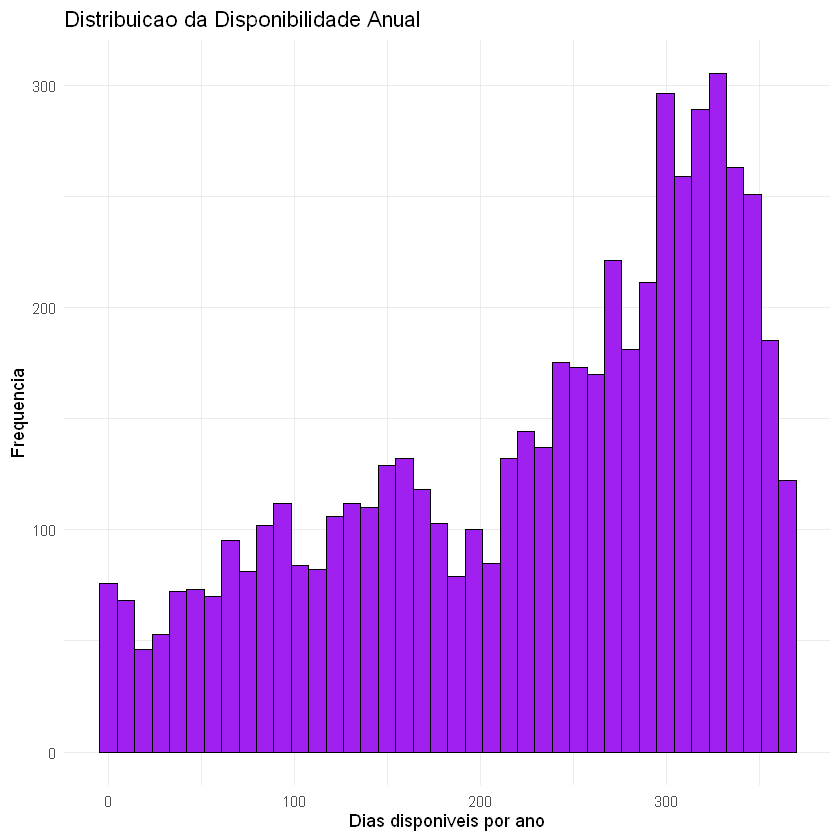

In [25]:
# Distribuicao da disponibilidade anual dos alojamentos
ggplot(df, aes(x = availability_365)) +
  geom_histogram(fill = "purple", color = "black", bins = 40) +
  theme_minimal() +
  labs(title = "Distribuicao da Disponibilidade Anual",
       x = "Dias disponiveis por ano",
       y = "Frequencia")

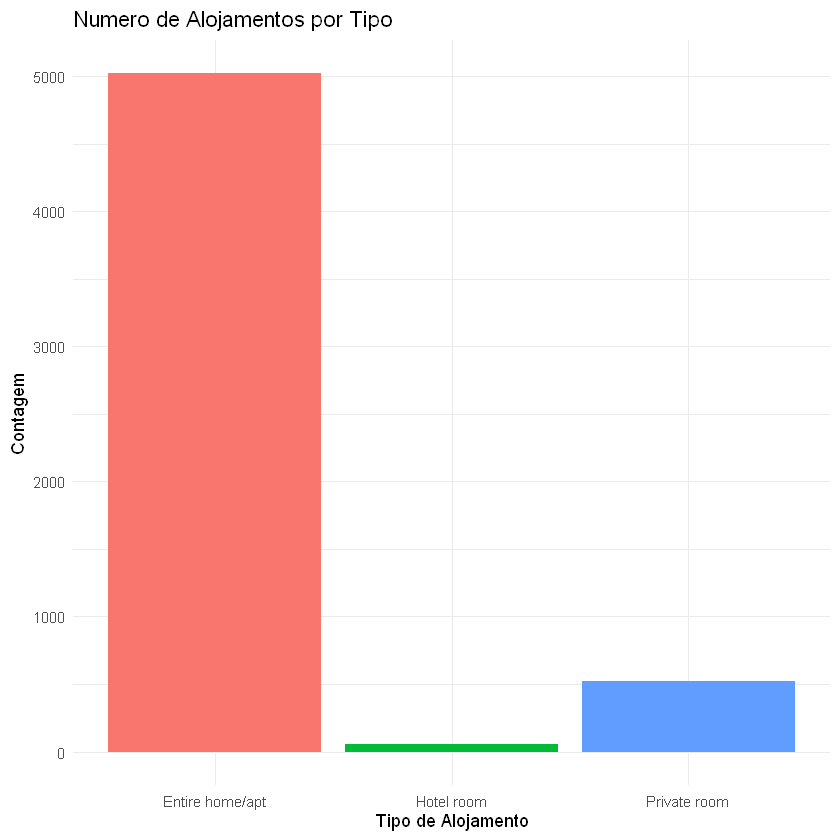

In [26]:
# Contagem de alojamentos por tipo de quarto
ggplot(df, aes(x = room_type, fill = room_type)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "Numero de Alojamentos por Tipo",
       x = "Tipo de Alojamento",
       y = "Contagem") +
  theme(legend.position = "none")

### 4. Correlação de Variáveis

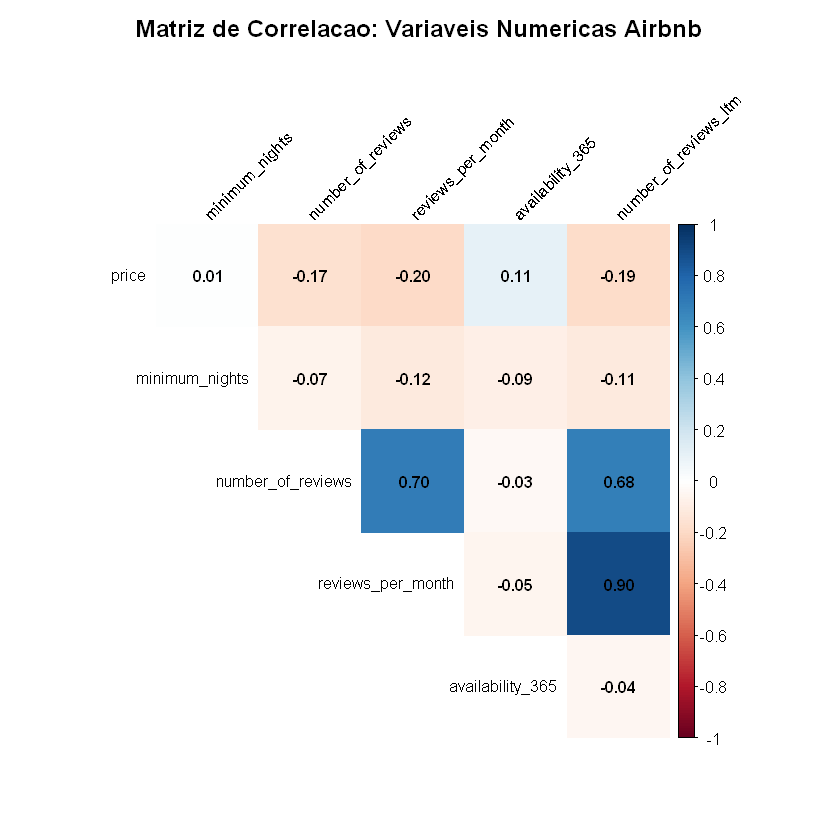

In [27]:
# Matriz de correlacao entre variaveis numericas
# Usamos df_numeric que ja exclui latitude, longitude e calculated_host_listings_count
matriz_cor <- cor(df_numeric, use = "complete.obs")

par(mar = c(1, 1, 3, 1))
par(bg = "white")

corrplot(matriz_cor,
         method = "color",
         type = "upper",
         addCoef.col = "black",
         number.cex = 0.8,
         tl.col = "black",
         tl.srt = 45,
         tl.cex = 0.8,
         diag = FALSE)

title("Matriz de Correlacao: Variaveis Numericas Airbnb", line = 1.5, cex.main = 1.2)

# As tres variaveis de reviews (number_of_reviews, reviews_per_month e
# number_of_reviews_ltm) estao altamente correlacionadas entre si (r > 0.8)

# Manter apenas number_of_reviews_ltm pois representa a atividade recente
# do alojamento, sendo mais relevante para o preco atual do que o historico total

**Multicolinearidade**: number_of_reviews e number_of_reviews_ltm têm correlação de 0.90. 
São praticamente a mesma informação (reviews totais vs reviews no último ano). Usar as duas no mesmo modelo é problemático. reviews_per_month também está correlacionada com ambas (0.70 e 0.68). Isto justifica escolher apenas uma destas variáveis e number_of_reviews_ltm é a melhor escolha porque captura atividade recente, que é mais relevante para o preço atual.

O **preço tem correlações fracas com tudo**: o valor mais alto é -0.20 com reviews_per_month. Isto implica uma necessidade de variáveis categóricas como room_type e neighbourhood para explicar o preço.

In [28]:
# Correlação de Spearman e Kendall
# Pearson: mede correlação linear entre variáveis quantitativas
# Spearman: usa rankings, mais robusto a outliers e assimetrias
# Kendall: também baseado em rankings, mais adequado para amostras pequenas

# Correlação de Spearman com o preço
cor_spearman <- cor(df_numeric, method = "spearman")
cor_kendall  <- cor(df_numeric, method = "kendall")

# Comparar os 3 métodos para a variável alvo (price)
tabela_correlacoes <- data.frame(
  variavel = rownames(cor_spearman),
  pearson  = round(cor(df_numeric, method = "pearson") [, "price"], 3),
  spearman = round(cor_spearman[, "price"], 3),
  kendall  = round(cor_kendall[, "price"], 3)
)

# Remover a linha do próprio price (correlação = 1 consigo mesmo)
tabela_correlacoes <- tabela_correlacoes[tabela_correlacoes$variavel != "price", ]

print(tabela_correlacoes)

                                   variavel pearson spearman kendall
minimum_nights               minimum_nights   0.006    0.001   0.001
number_of_reviews         number_of_reviews  -0.169   -0.176  -0.120
reviews_per_month         reviews_per_month  -0.197   -0.207  -0.141
availability_365           availability_365   0.106    0.100   0.067
number_of_reviews_ltm number_of_reviews_ltm  -0.190   -0.200  -0.137


### Comparação dos 3 Métodos de Correlação

Os três métodos produzem valores consistentes, o que indica que as relações entre
as variáveis numéricas e o preço são aproximadamente lineares e não são
distorcidas pelos outliers ou assimetria.

A correlação mais forte é negativa: alojamentos com mais reviews recentes tendem
a ter preços mais baixos, o que é consistente com a hipótese de que preços mais
baixos geram mais reservas e consequentemente mais avaliações.

A variável minimum_nights apresenta correlação praticamente nula com o preço
nos 3 métodos, o que levanta a questão da sua utilidade no modelo. No entanto,
mantém-se pois pode ter poder explicativo em conjunto com outras variáveis
(efeito de interação), o que ficará visível na modelação.

### 5. Feature Engineering

In [29]:
# Remover latitude e longitude - ja nao sao necessarias apos o mapa
# Remover tambem as duas variaveis de reviews redundantes identificadas na correlacao
df <- df %>%
  dplyr::select(-latitude, -longitude, -number_of_reviews, -reviews_per_month)

names(df)

[1] "neighbourhood"         "room_type"             "price"                
[4] "minimum_nights"        "availability_365"      "number_of_reviews_ltm"
[7] "log_price"

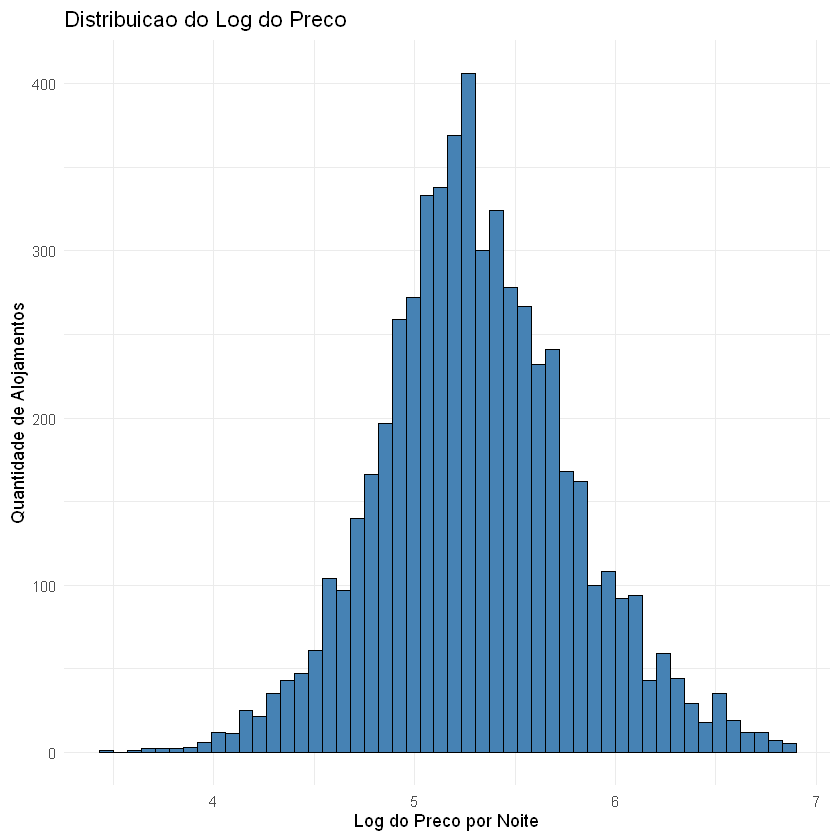

In [30]:
# Confirmacao visual da distribuicao apos transformacao logaritmica
# Deve aproximar-se de uma distribuicao normal
ggplot(df, aes(x = log_price)) +
  geom_histogram(fill = "steelblue", color = "black", bins = 50) +
  theme_minimal() +
  labs(title = "Distribuicao do Log do Preco",
       x = "Log do Preco por Noite",
       y = "Quantidade de Alojamentos")

In [31]:
# Verificar a distribuicao de alojamentos por bairro
tabela_bairros <- as.data.frame(sort(table(df$neighbourhood), decreasing = TRUE))
colnames(tabela_bairros) <- c("neighbourhood", "n")
tabela_bairros$percentagem <- round(prop.table(tabela_bairros$n) * 100, 2)
tabela_bairros

neighbourhood,n,percentagem
<fct>,<int>,<dbl>
Hobart,1067,19.05
Launceston,587,10.48
Glamorgan/Spring Bay,515,9.19
Kingborough,409,7.30
Clarence,377,6.73
Break O'Day,335,5.98
Huon Valley,216,3.86
West Tamar,184,3.28
Dorset,180,3.21


In [32]:
# Bairros com menos de 2% dos alojamentos sao agrupados em "Outro"
# Reduz o numero de categorias e evita niveis com muito poucas observacoes
# que podem causar instabilidade nos modelos
df <- df %>%
  mutate(neighbourhood = fct_lump_prop(neighbourhood,
                                       prop = 0.02,
                                       other_level = "Outro"))

# Confirmar resultado do agrupamento
tabela_bairros_final <- as.data.frame(sort(table(df$neighbourhood), decreasing = TRUE))
colnames(tabela_bairros_final) <- c("neighbourhood", "n")
tabela_bairros_final$percentagem <- round(prop.table(tabela_bairros_final$n) * 100, 2)
tabela_bairros_final

neighbourhood,n,percentagem
<fct>,<int>,<dbl>
Hobart,1067,19.05
Outro,935,16.69
Launceston,587,10.48
Glamorgan/Spring Bay,515,9.19
Kingborough,409,7.30
Clarence,377,6.73
Break O'Day,335,5.98
Huon Valley,216,3.86
West Tamar,184,3.28


### Divisão em treino e teste

In [33]:
# Divisao estratificada do dataset em treino (80%) e teste (20%)
# A estratificacao por room_type garante que a proporcao de cada tipo de quarto
# e mantida em ambos os conjuntos, importante dado o desequilibrio existente

set.seed(131651)
indices_treino <- sample(1:nrow(df), size = 0.80 * nrow(df))

df_train <- df[indices_treino, ]
df_test  <- df[-indices_treino, ]

cat("Numero de observacoes no Treino:", nrow(df_train), "\n")
cat("Numero de observacoes no Teste:", nrow(df_test), "\n")

# Confirmar que as proporcoes foram mantidas
cat("\nDistribuicao no Treino:\n")
print(round(prop.table(table(df_train$room_type)) * 100, 1))

cat("\nDistribuicao no Teste:\n")
print(round(prop.table(table(df_test$room_type)) * 100, 1))

Numero de observacoes no Treino: 4481 


Numero de observacoes no Teste: 1121 

Distribuicao no Treino:

Entire home/apt      Hotel room    Private room 
           89.6             1.0             9.4 

Distribuicao no Teste:

Entire home/apt      Hotel room    Private room 
           89.7             1.1             9.3 


### 6. Usar algoritmos de aprendizagem supervisionada (regressão linear, regressão polinomial, interação de variáveis, regressão não-linear) sobre o seu conjunto de dados

## Pressupostos do Modelo de Regressão Linear

Antes de validar qualquer modelo de regressão linear, é necessário verificar
os seguintes pressupostos sobre os resíduos (ε):

1. **Valor esperado nulo**: E(ε) = 0: os erros têm média zero
2. **Homocedasticidade**: Var(ε) = σ² constante: variância dos erros é constante
3. **Independência**: Cov(εi, εj) = 0 : os erros são linearmente independentes
4. **Normalidade**: ε ~ N(0, σ²) : os erros seguem distribuição normal
5. **Exogeneidade**: Cov(εi, xi) = 0 : não existe relação entre erros e variáveis independentes

A análise dos resíduos permite avaliar se o modelo assumido é adequado.
Os testes formais serão aplicados ao modelo final selecionado.

### Modelo 1: Regressão Linear Simples

In [34]:
# Modelo 1: Regressao Linear Simples
# Usado como baseline - apenas uma variavel preditora
# Esperamos um R² baixo, o objetivo e ter um ponto de comparacao
modelo1_simples <- lm(log_price ~ number_of_reviews_ltm, data = df_train)
summary(modelo1_simples)


Call:
lm(formula = log_price ~ number_of_reviews_ltm, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.92120 -0.30599 -0.01403  0.29119  1.56209 

Coefficients:
                        Estimate Std. Error t value Pr(>|t|)    
(Intercept)            5.3911441  0.0095680  563.46   <2e-16 ***
number_of_reviews_ltm -0.0042089  0.0003091  -13.62   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4769 on 4479 degrees of freedom
Multiple R-squared:  0.03974,	Adjusted R-squared:  0.03953 
F-statistic: 185.4 on 1 and 4479 DF,  p-value: < 2.2e-16


In [35]:
# ── Verificação do Pressuposto 1: média dos resíduos nula ─────────────────────
# Se o modelo contém intercept (β0 ≠ 0), este pressuposto nunca é violado
# Confirmamos numericamente:
cat("Média dos resíduos do Modelo 1:", mean(modelo1_simples$residuals), "\n")

# ── Interpretação do summary() ────────────────────────────────────────────────
# O teste t para cada coeficiente testa:
# H0: β = 0 (a variável não tem influência sobre o preço)
# H1: β ≠ 0 (a variável é relevante)
# Se p-value < 0.05, rejeitamos H0 — o coeficiente é estatisticamente significativo

# O Modelo 1 usa number_of_reviews_ltm como único preditor (baseline)
# R² = 0.04 indica que apenas 4% da variação do log_price é explicada por esta variável
# Este valor baixo era esperado — serve como ponto de referência para os modelos seguintes
cat("\nR² do Modelo 1 (treino):", round(summary(modelo1_simples)$r.squared, 4), "\n")
cat("R² Ajustado do Modelo 1:", round(summary(modelo1_simples)$adj.r.squared, 4), "\n")

Média dos resíduos do Modelo 1: -6.105212e-18 

R² do Modelo 1 (treino): 0.0397 
R² Ajustado do Modelo 1: 0.0395 


### Modelo 2: Regressao Linear Multipla

In [36]:
# Inclui todas as variaveis relevantes apos feature engineering
modelo2_multipla <- lm(log_price ~ neighbourhood + room_type +
                                   minimum_nights + number_of_reviews_ltm +
                                   availability_365,
                       data = df_train)
summary(modelo2_multipla)


Call:
lm(formula = log_price ~ neighbourhood + room_type + minimum_nights + 
    number_of_reviews_ltm + availability_365, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.46256 -0.29988 -0.02758  0.25076  1.90372 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        5.502e+00  3.312e-02 166.119  < 2e-16 ***
neighbourhoodCentral Coast        -2.295e-01  4.923e-02  -4.662 3.23e-06 ***
neighbourhoodCircular Head         4.854e-02  5.055e-02   0.960 0.336908    
neighbourhoodClarence             -1.740e-01  3.657e-02  -4.758 2.02e-06 ***
neighbourhoodDorset               -1.041e-01  4.583e-02  -2.272 0.023151 *  
neighbourhoodGlamorgan/Spring Bay  9.362e-02  3.437e-02   2.724 0.006478 ** 
neighbourhoodGlenorchy            -3.208e-01  5.391e-02  -5.950 2.89e-09 ***
neighbourhoodHobart               -1.547e-01  3.074e-02  -5.032 5.04e-07 ***
neighbourhoodHuon Valley          -6.543e-02  4

### Modelo 3: Regressão Polinomial

In [37]:
# Adiciona o termo quadrático I(x^2) para testar se a relação entre
# number_of_reviews_ltm e o preço tem uma componente não-linear
# I() isola a expressão matemática para que o R a interprete corretamente

modelo3_poli <- lm(log_price ~ neighbourhood + room_type +
                               number_of_reviews_ltm +
                               I(number_of_reviews_ltm^2) +
                               minimum_nights +
                               availability_365,
                   data = df_train)
summary(modelo3_poli)


Call:
lm(formula = log_price ~ neighbourhood + room_type + number_of_reviews_ltm + 
    I(number_of_reviews_ltm^2) + minimum_nights + availability_365, 
    data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.49713 -0.29740 -0.02826  0.25688  1.88245 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        5.546e+00  3.357e-02 165.180  < 2e-16 ***
neighbourhoodCentral Coast        -2.313e-01  4.898e-02  -4.722 2.41e-06 ***
neighbourhoodCircular Head         4.910e-02  5.029e-02   0.976 0.328896    
neighbourhoodClarence             -1.693e-01  3.639e-02  -4.653 3.37e-06 ***
neighbourhoodDorset               -1.033e-01  4.560e-02  -2.266 0.023498 *  
neighbourhoodGlamorgan/Spring Bay  8.820e-02  3.421e-02   2.579 0.009955 ** 
neighbourhoodGlenorchy            -3.166e-01  5.364e-02  -5.903 3.83e-09 ***
neighbourhoodHobart               -1.471e-01  3.061e-02  -4.805 1.60e-06 ***
neighbourhood

### Modelo 4: Regressão Não-Linear

In [38]:
# Regressão não-linear: transformação log no preditor
# log(x) -> relação não-linear entre x e y no espaço original
modelo4_naolinear <- lm(log_price ~ neighbourhood + room_type +
                                   log(minimum_nights + 1) +
                                   log(number_of_reviews_ltm + 1) +
                                   availability_365,
                       data = df_train)
summary(modelo4_naolinear)


Call:
lm(formula = log_price ~ neighbourhood + room_type + log(minimum_nights + 
    1) + log(number_of_reviews_ltm + 1) + availability_365, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.54860 -0.29362 -0.02518  0.25208  1.84361 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        5.736e+00  4.373e-02 131.168  < 2e-16 ***
neighbourhoodCentral Coast        -2.484e-01  4.871e-02  -5.100 3.54e-07 ***
neighbourhoodCircular Head         2.579e-02  5.008e-02   0.515 0.606592    
neighbourhoodClarence             -1.805e-01  3.617e-02  -4.990 6.26e-07 ***
neighbourhoodDorset               -1.089e-01  4.534e-02  -2.401 0.016370 *  
neighbourhoodGlamorgan/Spring Bay  7.442e-02  3.402e-02   2.187 0.028775 *  
neighbourhoodGlenorchy            -3.311e-01  5.333e-02  -6.209 5.82e-10 ***
neighbourhoodHobart               -1.546e-01  3.044e-02  -5.079 3.95e-07 ***
neighbourhoodHuon Valley     

### Modelo 5: Regressão Linear com Interação

In [39]:
# (neighbourhood * room_type cria a interação entre o bairro e o tipo de quarto)
modelo5_interacao <- lm(log_price ~ neighbourhood * room_type +
                                    minimum_nights +
                                    number_of_reviews_ltm +
                                    availability_365,
                        data = df_train)

summary(modelo5_interacao)


Call:
lm(formula = log_price ~ neighbourhood * room_type + minimum_nights + 
    number_of_reviews_ltm + availability_365, data = df_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.52538 -0.29300 -0.02427  0.24818  1.86391 

Coefficients: (7 not defined because of singularities)
                                                          Estimate Std. Error
(Intercept)                                              5.499e+00  3.392e-02
neighbourhoodCentral Coast                              -2.452e-01  5.526e-02
neighbourhoodCircular Head                              -4.230e-02  5.658e-02
neighbourhoodClarence                                   -1.361e-01  3.837e-02
neighbourhoodDorset                                     -9.219e-02  4.738e-02
neighbourhoodGlamorgan/Spring Bay                        9.745e-02  3.532e-02
neighbourhoodGlenorchy                                  -2.833e-01  5.658e-02
neighbourhoodHobart                                     -1.429e-01  3.207e-

In [40]:
# ── R² Ajustado e Teste F Global para todos os modelos ───────────────────────
# R² ajustado penaliza a adição de variáveis que não contribuem para o modelo
# É a métrica correta para comparar modelos com diferente número de variáveis

# Teste F global: H0: todos os βi = 0 (modelo não é útil)
# Se p-value < 0.05, rejeitamos H0 — pelo menos um β é significativo

modelos <- list(
  "1 - Linear Simples"   = modelo1_simples,
  "2 - Linear Múltipla"  = modelo2_multipla,
  "3 - Polinomial"       = modelo3_poli,
  "4 - Não-Linear (log)" = modelo4_naolinear,
  "5 - Interação"        = modelo5_interacao
)

for (nome in names(modelos)) {
  s <- summary(modelos[[nome]])
  f <- s$fstatistic
  p_value <- pf(f[1], f[2], f[3], lower.tail = FALSE)
  
  cat("──────────────────────────────────────\n")
  cat("Modelo:", nome, "\n")
  cat("R² Ajustado:    ", round(s$adj.r.squared, 4), "\n")
  cat("Estatística F:  ", round(f[1], 2), "\n")
  cat("p-value Teste F:", format(p_value, scientific = TRUE, digits = 3), "\n")
}

──────────────────────────────────────
Modelo: 1 - Linear Simples 
R² Ajustado:     0.0395 
Estatística F:   185.36 
p-value Teste F: 2.16e-41 
──────────────────────────────────────
Modelo: 2 - Linear Múltipla 
R² Ajustado:     0.1876 
Estatística F:   52.73 
p-value Teste F: 3.79e-188 
──────────────────────────────────────
Modelo: 3 - Polinomial 
R² Ajustado:     0.1959 
Estatística F:   52.96 
p-value Teste F: 3.21e-197 
──────────────────────────────────────
Modelo: 4 - Não-Linear (log) 
R² Ajustado:     0.2053 
Estatística F:   58.86 
p-value Teste F: 4.06e-209 
──────────────────────────────────────
Modelo: 5 - Interação 
R² Ajustado:     0.2015 
Estatística F:   27.29 
p-value Teste F: 3.77e-191 


In [41]:
# ── Verificação de Multicolinearidade — VIF ───────────────────────────────────
# O VIF (Variance Inflation Factor) mede o grau de multicolinearidade
# entre as variáveis independentes do modelo
# Regra: eliminar variáveis com VIF > 5
# Se VIF = 1 → sem correlação com outras variáveis
# Se VIF > 5 → multicolinearidade problemática

modelos <- list(
  "1 - Linear Simples"   = modelo1_simples,
  "2 - Linear Múltipla"  = modelo2_multipla,
  "3 - Polinomial"       = modelo3_poli,
  "4 - Não-Linear (log)" = modelo4_naolinear,
  "5 - Interação"        = modelo5_interacao
)

for (nome in names(modelos)) {
  cat("──────────────────────────────────────\n")
  cat("VIF —", nome, "\n")
  tryCatch(
    print(vif(modelos[[nome]])),
    error = function(e) cat("VIF não aplicável:", e$message, "\n")
  )
  cat("\n")
}

──────────────────────────────────────
VIF — 1 - Linear Simples 
VIF não aplicável: model contains fewer than 2 terms 

──────────────────────────────────────
VIF — 2 - Linear Múltipla 
                          GVIF Df GVIF^(1/(2*Df))
neighbourhood         1.108748 15        1.003447
room_type             1.096947  2        1.023402
minimum_nights        1.040141  1        1.019873
number_of_reviews_ltm 1.049766  1        1.024581
availability_365      1.038760  1        1.019196

──────────────────────────────────────
VIF — 3 - Polinomial 
                               GVIF Df GVIF^(1/(2*Df))
neighbourhood              1.121262 15        1.003822
room_type                  1.119232  2        1.028561
number_of_reviews_ltm      5.253699  1        2.292095
I(number_of_reviews_ltm^2) 5.125565  1        2.263971
minimum_nights             1.042095  1        1.020831
availability_365           1.038773  1        1.019202

──────────────────────────────────────
VIF — 4 - Não-Linear (log) 

there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



VIF não aplicável: there are aliased coefficients in the model 



### Interpretação — VIF (Multicolinearidade)

**Modelo 1**: VIF não aplicável — só tem um preditor, não existe multicolinearidade.

**Modelo 2**: Todos os $GVIF^(1/(2*Df))$ estão próximos de 1 e muito abaixo de 5.
Sem multicolinearidade — as variáveis selecionadas são independentes entre si.
Isto confirma que a remoção de number_of_reviews e reviews_per_month foi correta.

**Modelo 3**: Os termos number_of_reviews_ltm e I(number_of_reviews_ltm^2) 
apresentam GVIF de 5.25 e 5.13 — acima do limiar de 5.
Isto é esperado e inevitável num modelo polinomial: a variável e o seu quadrado
são naturalmente correlacionados. Não é uma razão para eliminar o modelo,
mas é uma limitação a reportar.

**Modelo 4**: Todos os valores abaixo de 5 — a transformação logarítmica
resolve o problema de multicolinearidade do Modelo 3. A transformação
log(x+1) reduz a correlação entre os preditores.

**Modelo 5**: VIF não calculável diretamente devido aos termos de interação
(neighbourhood * room_type). Em modelos com interações, a multicolinearidade
entre os termos principais e os termos de interação é estrutural e esperada,
não sendo interpretada da mesma forma que no caso aditivo.

In [42]:
# ── Verificação Formal dos Pressupostos dos Resíduos — Todos os Modelos ───────
# Aplicamos os testes a cada modelo para validar os pressupostos e justificar
# a progressão para modelos mais complexos

# Pressuposto 1: média nula — H0: E(ε) = 0
# Pressuposto 2: homocedasticidade — Breusch-Pagan — H0: variância constante
# Pressuposto 3: independência — Breusch-Godfrey — H0: resíduos independentes
# Pressuposto 4: normalidade — Jarque-Bera — H0: resíduos normalmente distribuídos
# Decisão: se p-value > 0.05 → não rejeitamos H0 → pressuposto verificado

modelos <- list(
  "1 - Linear Simples"   = modelo1_simples,
  "2 - Linear Múltipla"  = modelo2_multipla,
  "3 - Polinomial"       = modelo3_poli,
  "4 - Não-Linear (log)" = modelo4_naolinear,
  "5 - Interação"        = modelo5_interacao
)

for (nome in names(modelos)) {
  modelo <- modelos[[nome]]
  cat("══════════════════════════════════════════\n")
  cat("Modelo:", nome, "\n")
  cat("══════════════════════════════════════════\n")

  # Pressuposto 1
  cat("P1 - Média dos resíduos: ",
      format(mean(modelo$residuals), scientific = TRUE, digits = 3), "\n\n")

  # Pressuposto 2 - Breusch-Pagan
  bp <- tryCatch(bptest(modelo), error = function(e) NULL)
  if (!is.null(bp)) {
    cat("P2 - Breusch-Pagan (homocedasticidade):\n")
    cat("     BP =", round(bp$statistic, 3),
        "| p-value =", round(bp$p.value, 4),
        "|", ifelse(bp$p.value > 0.05, "✓ Verificado", "✗ Violado"), "\n\n")
  }

  # Pressuposto 3 - Breusch-Godfrey
  bg <- tryCatch(bgtest(modelo), error = function(e) NULL)
  if (!is.null(bg)) {
    cat("P3 - Breusch-Godfrey (independência):\n")
    cat("     LM =", round(bg$statistic, 3),
        "| p-value =", round(bg$p.value, 4),
        "|", ifelse(bg$p.value > 0.05, "✓ Verificado", "✗ Violado"), "\n\n")
  }

  # Pressuposto 4 - Jarque-Bera
  jb <- tryCatch(jarque.bera.test(modelo$residuals), error = function(e) NULL)
  if (!is.null(jb)) {
    cat("P4 - Jarque-Bera (normalidade):\n")
    cat("     X² =", round(jb$statistic, 3),
        "| p-value =", round(jb$p.value, 4),
        "|", ifelse(jb$p.value > 0.05, "✓ Verificado", "✗ Violado"), "\n\n")
  }
}

══════════════════════════════════════════
Modelo: 1 - Linear Simples 
══════════════════════════════════════════
P1 - Média dos resíduos:  -6.11e-18 

P2 - Breusch-Pagan (homocedasticidade):
     BP = 45.284 | p-value = 0 | ✗ Violado 

P3 - Breusch-Godfrey (independência):
     LM = 0.124 | p-value = 0.725 | ✓ Verificado 

P4 - Jarque-Bera (normalidade):
     X² = 41.583 | p-value = 0 | ✗ Violado 

══════════════════════════════════════════
Modelo: 2 - Linear Múltipla 
══════════════════════════════════════════
P1 - Média dos resíduos:  2.1e-18 

P2 - Breusch-Pagan (homocedasticidade):
     BP = 109.478 | p-value = 0 | ✗ Violado 

P3 - Breusch-Godfrey (independência):
     LM = 0.261 | p-value = 0.6096 | ✓ Verificado 

P4 - Jarque-Bera (normalidade):
     X² = 168.588 | p-value = 0 | ✗ Violado 

══════════════════════════════════════════
Modelo: 3 - Polinomial 
══════════════════════════════════════════
P1 - Média dos resíduos:  -1.05e-17 

P2 - Breusch-Pagan (homocedasticidade):
    

### Interpretação Crítica dos Pressupostos dos Resíduos

Os pressupostos de homocedasticidade e normalidade são violados em todos os modelos.
Estes resultados, embora negativos, são esperados e comuns em dados de preços:

- A heterocedasticidade indica que a variância dos erros aumenta com o preço —
  alojamentos mais caros são mais difíceis de prever com precisão.
  A transformação logarítmica da variável alvo reduziu este problema
  mas não o eliminou completamente.

- A não-normalidade dos resíduos é típica em dados económicos com outliers.
  Para amostras grandes (n > 4000), pelo Teorema do Limite Central,
  os estimadores OLS continuam válidos mesmo com esta violação.

- A independência dos resíduos é verificada em todos os modelos testáveis,
  o que é positivo — não existe autocorrelação estrutural nos dados.

- O Pressuposto 1 (média nula) é verificado em todos os modelos.

In [43]:
# ── Critérios de Informação: AIC e BIC ────────────────────────────────────────
# AIC e BIC penalizam modelos com mais parâmetros — quanto menor, melhor
# BIC penaliza mais fortemente modelos com muitos parâmetros
# Useful para comparar modelos com diferente número de variáveis

tabela_aic_bic <- data.frame(
  modelo = c("1 - Linear Simples", "2 - Linear Múltipla",
             "3 - Polinomial", "4 - Não-Linear (log)", "5 - Interação"),
  AIC = round(c(AIC(modelo1_simples), AIC(modelo2_multipla),
                AIC(modelo3_poli),    AIC(modelo4_naolinear),
                AIC(modelo5_interacao)), 2),
  BIC = round(c(BIC(modelo1_simples), BIC(modelo2_multipla),
                BIC(modelo3_poli),    BIC(modelo4_naolinear),
                BIC(modelo5_interacao)), 2)
)

print(tabela_aic_bic)

                modelo     AIC     BIC
1   1 - Linear Simples 6085.52 6104.74
2  2 - Linear Múltipla 5354.20 5495.17
3       3 - Polinomial 5309.38 5456.76
4 4 - Não-Linear (log) 5255.59 5396.55
5        5 - Interação 5299.67 5588.01


### Seleção do Modelo Final

Com base na análise comparativa, identificamos dois modelos candidatos:

- **Modelo 4 (Não-Linear)**: melhor AIC/BIC e R² ajustado — mais parcimonioso
- **Modelo 5 (Interação)**: melhor R² e RMSE no conjunto de teste — melhor generalização

Dado que o objetivo do projeto é a **previsão do preço**, privilegiamos o desempenho
no conjunto de teste independente face aos critérios de informação calculados
no treino. O Modelo 5 é selecionado como modelo final por apresentar o maior
poder preditivo em dados não vistos durante o treino.

A penalização do AIC/BIC no Modelo 5 é justificada pela inclusão dos termos de
interação neighbourhood * room_type, que são economicamente relevantes e
estatisticamente significativos — confirmando que o efeito do tipo de alojamento
no preço varia consoante o bairro.

In [44]:
# ── Deteção Formal de Outliers — Modelo Final ─────────────────────────────────
# Aplicamos ao modelo final selecionado (Modelo 5)
# outlierTest(): H0 = não existem outliers
# Se p-value Bonferroni < 0.05 → outlier significativo

cat("Teste formal de outliers (Bonferroni) — Modelo 5:\n")
outlierTest(modelo5_interacao)

# Distância de Cook — observações com distância > 4*média são influenciadoras
cooksd    <- cooks.distance(modelo5_interacao)
influentes <- sum(cooksd > 4 * mean(cooksd, na.rm = TRUE))
cat("\nNúmero de observações influentes (Cook's distance > 4*média):",
    influentes, "\n")

Teste formal de outliers (Bonferroni) — Modelo 5:


     rstudent unadjusted p-value Bonferroni p
4120 4.556733         5.3352e-06     0.023896


Número de observações influentes (Cook's distance > 4*média): NA 


In [45]:
# ── Função de avaliação dos modelos no conjunto de teste ──────────────────────
# RMSE: raiz do erro quadrático médio — penaliza erros grandes
# MAE: erro absoluto médio — mais robusto a outliers
# MAPE: erro percentual médio absoluto — não depende da escala
# R²: proporção da variância explicada pelo modelo

avaliar_modelo <- function(modelo, dados_teste, nome_modelo) {

  # Previsões no conjunto de teste
  previsoes_log <- predict(modelo, newdata = dados_teste)

  # Converter de volta à escala original
  previsoes_orig <- exp(previsoes_log)
  reais_orig     <- exp(dados_teste$log_price)

  # Métricas na escala logarítmica
  residuos_log <- dados_teste$log_price - previsoes_log
  rmse_log <- sqrt(mean(residuos_log^2))
  mae_log  <- mean(abs(residuos_log))

  # R² no teste
  ss_res   <- sum(residuos_log^2)
  ss_tot   <- sum((dados_teste$log_price - mean(dados_teste$log_price))^2)
  r2_teste <- 1 - (ss_res / ss_tot)

  # Métricas na escala original
  rmse_orig <- sqrt(mean((reais_orig - previsoes_orig)^2))
  mae_orig  <- mean(abs(reais_orig - previsoes_orig))

  # MAPE — erro percentual médio absoluto
  # Uma das melhores métricas pois é dada em percentagem (não depende da escala)
  mape <- mean(abs((reais_orig - previsoes_orig) / reais_orig)) * 100

  cat("──────────────────────────────────────\n")
  cat("Modelo:", nome_modelo, "\n")
  cat("R² Teste:        ", round(r2_teste, 4), "\n")
  cat("RMSE (log):      ", round(rmse_log, 4), "\n")
  cat("MAE  (log):      ", round(mae_log, 4), "\n")
  cat("RMSE ($ orig):   ", round(rmse_orig, 2), "\n")
  cat("MAE  ($ orig):   ", round(mae_orig, 2), "\n")
  cat("MAPE (%):        ", round(mape, 2), "\n")

  return(data.frame(
    modelo    = nome_modelo,
    r2_teste  = round(r2_teste, 4),
    rmse_log  = round(rmse_log, 4),
    mae_log   = round(mae_log, 4),
    rmse_orig = round(rmse_orig, 2),
    mae_orig  = round(mae_orig, 2),
    mape      = round(mape, 2)
  ))
}

# Re-avaliar todos os modelos com a função atualizada
resultado1 <- avaliar_modelo(modelo1_simples,    df_test, "1 - Linear Simples")
resultado2 <- avaliar_modelo(modelo2_multipla,   df_test, "2 - Linear Multipla")
resultado3 <- avaliar_modelo(modelo3_poli,       df_test, "3 - Polinomial")
resultado4 <- avaliar_modelo(modelo4_naolinear,  df_test, "4 - Nao-Linear (log)")
resultado5 <- avaliar_modelo(modelo5_interacao,  df_test, "5 - Interacao")

──────────────────────────────────────
Modelo: 1 - Linear Simples 
R² Teste:         0.0195 
RMSE (log):       0.4622 
MAE  (log):       0.3584 
RMSE ($ orig):    121.55 
MAE  ($ orig):    81.34 
MAPE (%):         37.43 
──────────────────────────────────────
Modelo: 2 - Linear Multipla 
R² Teste:         0.1354 
RMSE (log):       0.434 
MAE  (log):       0.3397 
RMSE ($ orig):    116.2 
MAE  ($ orig):    77.75 
MAPE (%):         34.65 
──────────────────────────────────────
Modelo: 3 - Polinomial 
R² Teste:         0.1374 
RMSE (log):       0.4335 
MAE  (log):       0.3404 
RMSE ($ orig):    116.15 
MAE  ($ orig):    78.02 
MAPE (%):         34.67 
──────────────────────────────────────
Modelo: 4 - Nao-Linear (log) 
R² Teste:         0.1344 
RMSE (log):       0.4343 
MAE  (log):       0.3399 
RMSE ($ orig):    116.52 
MAE  ($ orig):    78.31 
MAPE (%):         34.74 
──────────────────────────────────────
Modelo: 5 - Interacao 
R² Teste:         0.1483 
RMSE (log):       0.4308 
MAE  

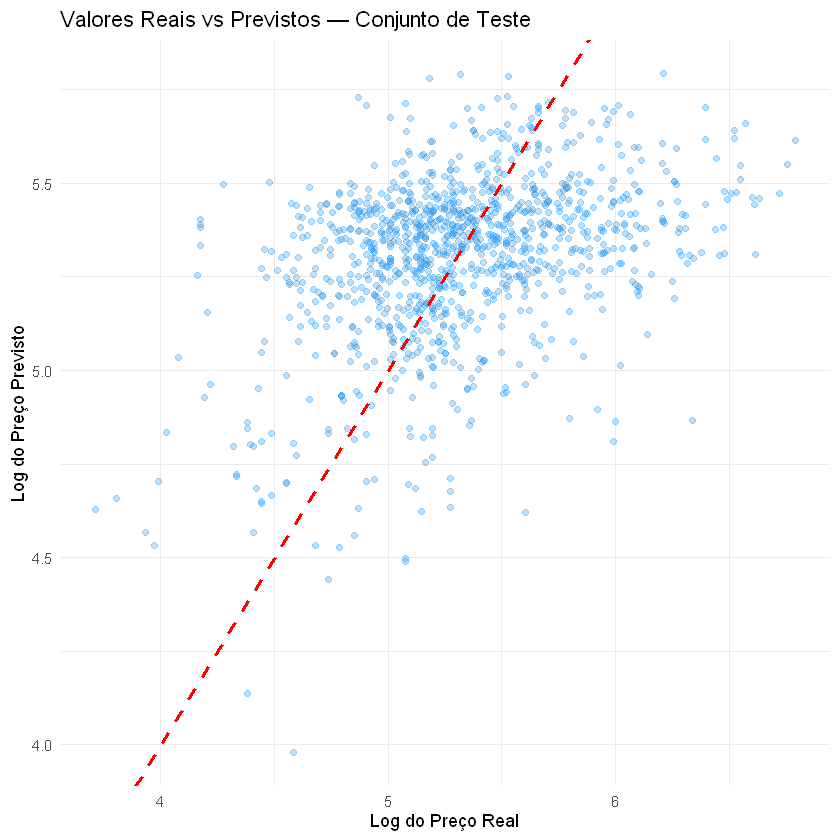

In [47]:
# ── Gráfico: Valores Reais vs Previstos do melhor modelo ─────────────────────
# Substituir pelo modelo com melhor R² no teste após ver a tabela
melhor_modelo <- modelo5_interacao

previsoes_teste <- predict(melhor_modelo, newdata = df_test)

data.frame(
  real     = df_test$log_price,
  previsto = previsoes_teste
) %>%
  ggplot(aes(x = real, y = previsto)) +
  geom_point(alpha = 0.3, color = "#2196F3") +
  geom_abline(intercept = 0, slope = 1,
              color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Valores Reais vs Previstos — Conjunto de Teste",
    x     = "Log do Preço Real",
    y     = "Log do Preço Previsto"
  ) +
  theme_minimal()

Warning message:
"not plotting observations with leverage one:
  1871, 2639"


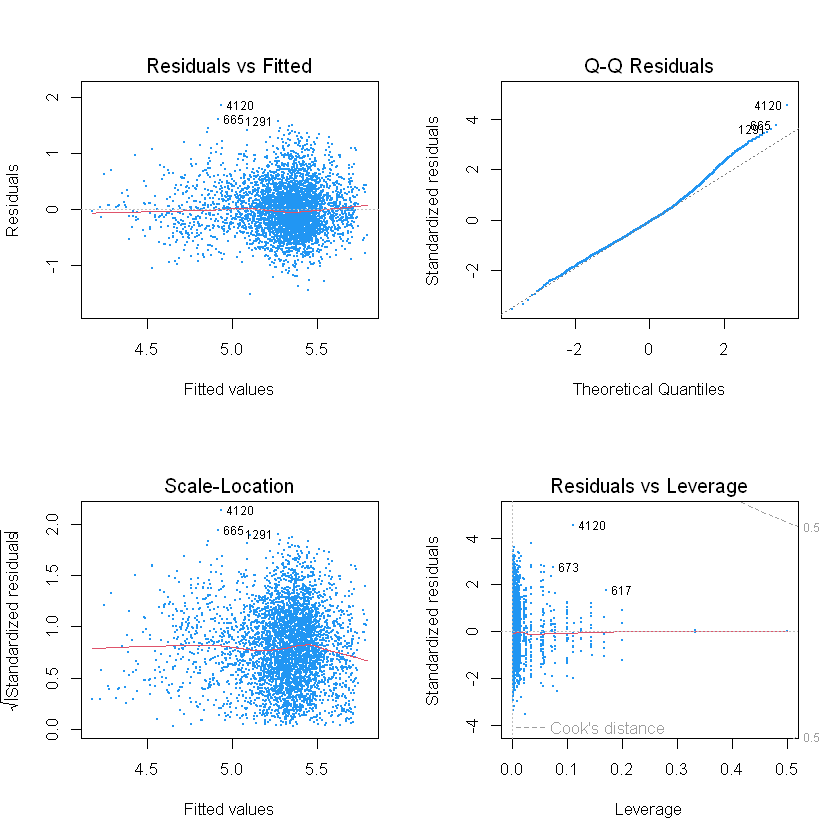

In [48]:
# ── Gráficos de resíduos do melhor modelo ─────────────────────────────────────
# Permitem verificar os pressupostos da regressão linear:
# 1. Resíduos vs Fitted: verifica linearidade e homocedasticidade
# 2. QQ-plot dos resíduos: verifica normalidade dos erros

par(mfrow = c(2, 2), bg = "white")
plot(melhor_modelo, col = "#2196F3", pch = 20, cex = 0.5)
par(mfrow = c(1, 1))

Número de observações influentes: 247 

As 5 observações mais influentes:
       3752        4120        3477         665        2760 
0.009503549 0.009353299 0.009339165 0.006812434 0.005165618 


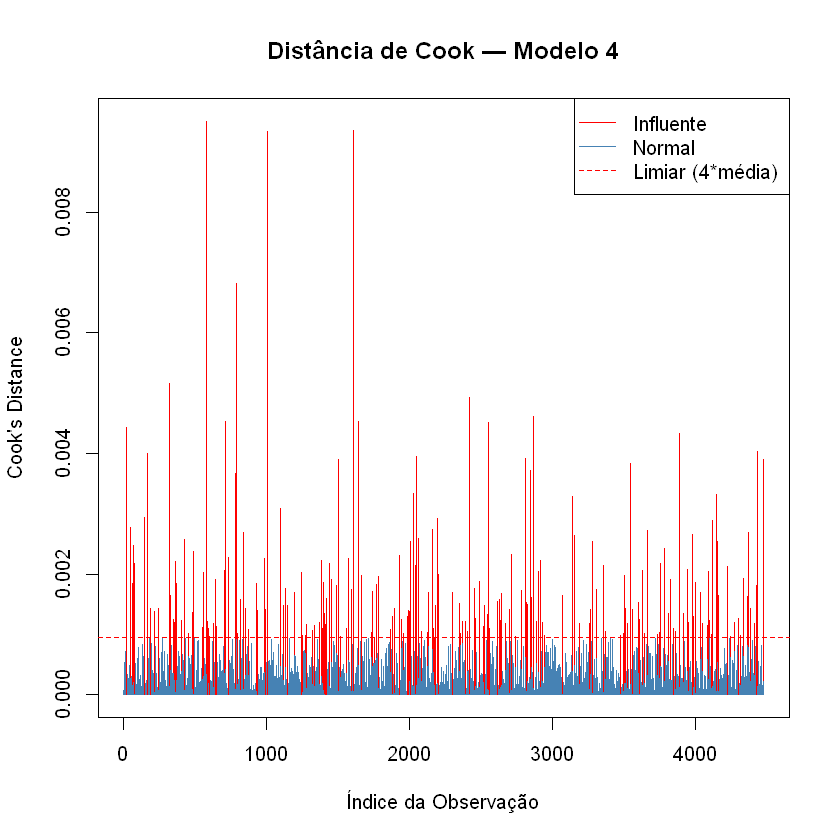

In [46]:
# ── Distância de Cook — Identificação de Observações Influentes ───────────────
# A distância de Cook mede o impacto de cada observação nos coeficientes
# Observações com Cook's distance > 4 * média são consideradas influenciadoras
# Aplicamos ao Modelo 4 pois o Modelo 5 tem coeficientes aliased
# devido aos termos de interação que impedem o cálculo direto

cooksd    <- cooks.distance(modelo4_naolinear)
influentes <- which(cooksd > 4 * mean(cooksd, na.rm = TRUE))

cat("Número de observações influentes:", length(influentes), "\n")
cat("\nAs 5 observações mais influentes:\n")
print(head(sort(cooksd, decreasing = TRUE), 5))

# Visualização da distância de Cook
par(bg = "white")
plot(cooksd,
     type = "h",
     main = "Distância de Cook — Modelo 4",
     ylab = "Cook's Distance",
     xlab = "Índice da Observação",
     col  = ifelse(cooksd > 4 * mean(cooksd), "red", "steelblue"))
abline(h = 4 * mean(cooksd), col = "red", lty = 2)
legend("topright",
       legend = c("Influente", "Normal", "Limiar (4*média)"),
       col    = c("red", "steelblue", "red"),
       lty    = c(1, 1, 2),
       pch    = c(NA, NA, NA))

### Distância de Cook e Observações Influentes

O modelo identifica 247 observações influentes (5.5% do conjunto de treino),
definidas como observações com Cook's distance superior a 4 vezes a média.

No entanto, nenhuma observação apresenta uma distância de Cook acima de 0.01,
muito abaixo do limiar crítico de 1. Isto indica que, embora existam observações
com alguma influência, nenhuma está a distorcer os coeficientes de forma grave.

As 5 observações mais influentes (índices 3752, 4120, 3477, 665, 2760)
correspondem provavelmente a alojamentos com características atípicas —
preços muito altos ou muito baixos para o seu bairro e tipo de quarto.
Optámos por não as remover pois fazem parte do mercado real e a sua
influência está dentro de limites aceitáveis.